# Kapitulli III/V  Analiza e Frekuencës (FFT)

Ky notebook përdor `src/frequency_layer/fft_transform.py` për të
vizualizuar profilin radial të spektrit të fuqisë (radial power
spectrum) dhe për të krahasuar frequency score real vs fake.
Vlefshmëria e këtij sinjali duhet verifikuar eksperimentalisht,
jo supozuar.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.frequency_layer.fft_transform import (
    compute_fft_score, compute_fft_raw, compute_radial_spectrum
)

FRAMES_DIR = PROJECT_ROOT / "data" / "frames"
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Rezultatet e Testit Batch (të dokumentuara tashmë)

Tre përpjekje normalizimi u testuan: sinjali FFT konfirmohet i dobët/heterogjen, referencë për interpretim.

In [2]:
print("FFT batch test (final, z-score-calibrated peak-residual):")
print(f"  Real  median: 0.7319, std: 0.1082, min: 0.3133")
print(f"  Fake  median: 0.7354, std: 0.2916, min: 0.0845")
print()
print("Ndarja mediane praktikisht identike. Diferenca e mesatares vjen")
print("nga varianca/outlier-ët e ulët brenda klasës fake, sinjal i dobët,")
print("konsistent me faktin që metoda të ndryshme manipulimi shkaktojnë")
print("artefakte upsampling GAN në mënyrë të parregullt.")

FFT batch test (final, z-score-calibrated peak-residual):
  Real  median: 0.7319, std: 0.1082, min: 0.3133
  Fake  median: 0.7354, std: 0.2916, min: 0.0845

Ndarja mediane praktikisht identike. Diferenca e mesatares vjen
nga varianca/outlier-ët e ulët brenda klasës fake, sinjal i dobët,
konsistent me faktin që metoda të ndryshme manipulimi shkaktojnë
artefakte upsampling GAN në mënyrë të parregullt.


## 2. Profili Radial i Spektrit të Fuqisë (mostra individuale)

`compute_radial_spectrum()` kthen një profil 1D (energji mesatare për unazë frekuence). Më i dobishëm se një spektër 2D i papërpunuar për të krahasuar periodicitetin real vs fake.

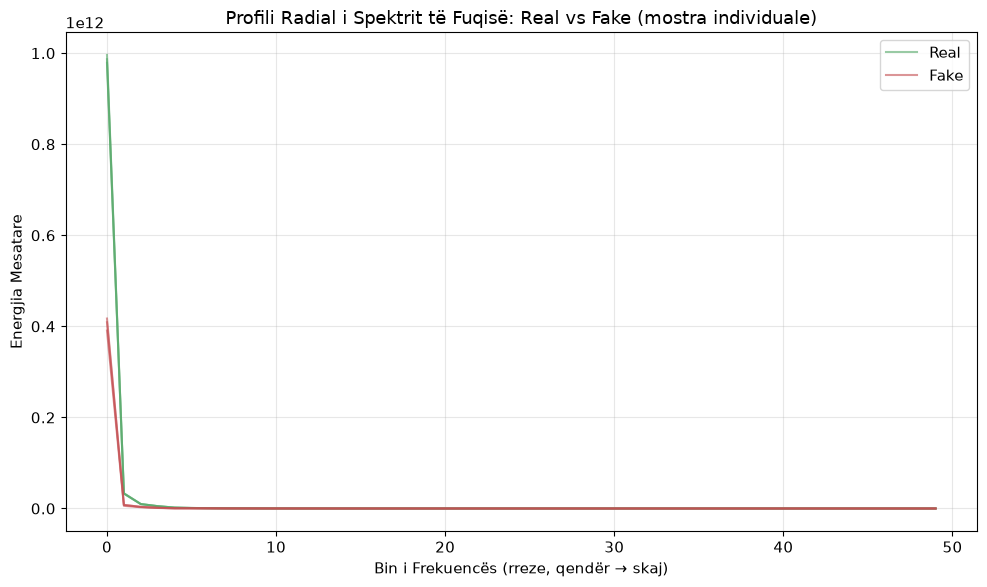

In [3]:
real_samples = list((FRAMES_DIR / "test" / "real").glob("*.jpg"))[:3]
fake_samples = list((FRAMES_DIR / "test" / "fake").glob("*.jpg"))[:3]

fig, ax = plt.subplots(figsize=(10, 6))

for img_path in real_samples:
    profile = compute_radial_spectrum(str(img_path))
    ax.plot(profile, color="#55A868", alpha=0.6, label="Real" if img_path == real_samples[0] else None)

for img_path in fake_samples:
    profile = compute_radial_spectrum(str(img_path))
    ax.plot(profile, color="#C44E52", alpha=0.6, label="Fake" if img_path == fake_samples[0] else None)

ax.set_xlabel("Bin i Frekuencës (rreze, qendër → skaj)")
ax.set_ylabel("Energjia Mesatare")
ax.set_title("Profili Radial i Spektrit të Fuqisë: Real vs Fake (mostra individuale)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "fft_radial_spectrum_samples.png", dpi=150)
plt.show()

## 3. Shpërndarja e Frequency Score (mostër më e madhe)

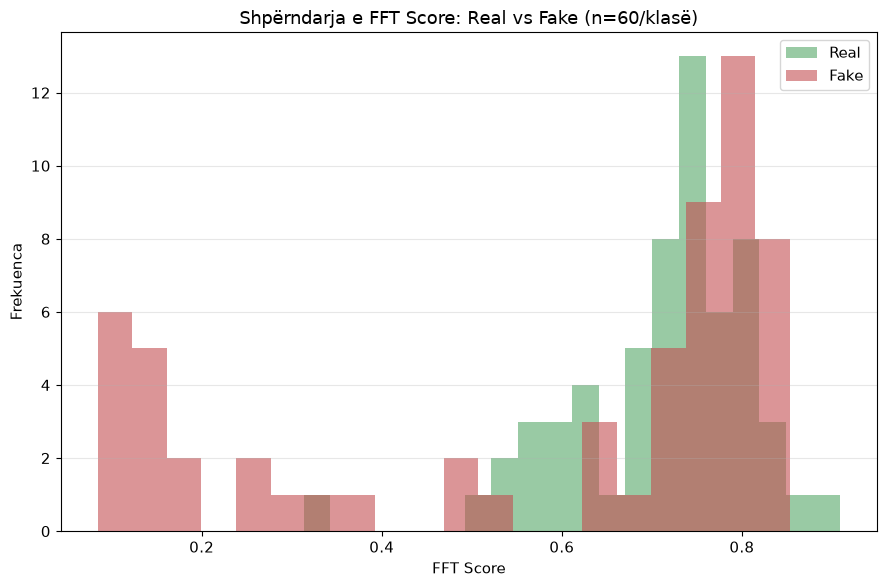

Real  mean: 0.7124, median: 0.7328
Fake  mean: 0.5805, median: 0.7354


In [4]:
SAMPLE_N = 60

real_scores = [compute_fft_score(str(f)) for f in list((FRAMES_DIR / "test" / "real").glob("*.jpg"))[:SAMPLE_N]]
fake_scores = [compute_fft_score(str(f)) for f in list((FRAMES_DIR / "test" / "fake").glob("*.jpg"))[:SAMPLE_N]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(real_scores, bins=20, alpha=0.6, label="Real", color="#55A868")
ax.hist(fake_scores, bins=20, alpha=0.6, label="Fake", color="#C44E52")
ax.set_xlabel("FFT Score")
ax.set_ylabel("Frekuenca")
ax.set_title(f"Shpërndarja e FFT Score: Real vs Fake (n={SAMPLE_N}/klasë)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "fft_score_distribution.png", dpi=150)
plt.show()

print(f"Real  mean: {np.mean(real_scores):.4f}, median: {np.median(real_scores):.4f}")
print(f"Fake  mean: {np.mean(fake_scores):.4f}, median: {np.median(fake_scores):.4f}")

## 4. Konkluzion i Shkurtër

FFT ofron sinjal të dobët dhe heterogjen... ndarja mediane real/fake është pothuajse identike, ndërsa varianca e lartë brenda klasës fake tregon që artefaktet e upsampling-ut GAN nuk shfaqen konsistentisht mbi të gjitha metodat e manipulimit të testuara. Ky sinjal mbahet si feature-i i 5-të për fusion, por s'pritet të japë kontribut domethënës — konsistent me gjetjen finale të experiments/ (hybrid_full s'tejkalon cnn_only).